# Joint Fitting example

This notebook covers how to perform joint optimization and inference for multiple datasets simultaneously, using nDspec's fit objects. As an example, we will jointly fit two spectra extracted from NuSTAR's FPMs, but the analysis here is identical no matter what data (or type of data) you want to combine, whether they be time-averaged spectra, lags, or something else.

As usual we will begin by importing the required libraries:

In [1]:
import os
import sys
sys.path.append('/home/matteo/Software/nDspec/src/')

import numpy as np

import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)
import matplotlib.pyplot as plt

from ndspec.Response import ResponseMatrix
import ndspec.FitTimeAvgSpectrum as fitspec
import ndspec.Models as models
import ndspec.XspecInterface as XSModels

from lmfit import Model as LM_Model

## Loading Data

Setting up a joint requires first setting up one separate fitter object (regardless of type) for each dataset we want to consider. In our case, we will use two FitTimeAvgSpectrum objects, one for each FPM. As in the tutorial on [fitting a time averaged spectrum](fit_spec.ipynb), we need to load the response matrices first, after which we will load our spectra, restrict the energy range, and plot each to make sure the loading worked correctly:

In [2]:
nustar = os.getcwd() + "/data/"

rmfpath = nustar + "/nu90401309004A01_sr.rmf"
fpma_04 = ResponseMatrix(rmfpath)
arfpath = nustar + "/nu90401309004A01_sr.arf"
fpma_04.load_arf(arfpath)

rmfpath = nustar + "/nu90401309004B01_sr.rmf"
fpmb_04 = ResponseMatrix(rmfpath)
arfpath = nustar + "/nu90401309004B01_sr.arf"
fpmb_04.load_arf(arfpath)

Arf missing, please load it
Arf loaded
Arf missing, please load it
Arf loaded


/home/matteo/Software/nDspec/src/ndspec/SimpleFit.py:851: UserWarning: WARNING: found backscal=0, assuming it is 1
  warnings.warn("WARNING: found backscal=0, assuming it is 1",


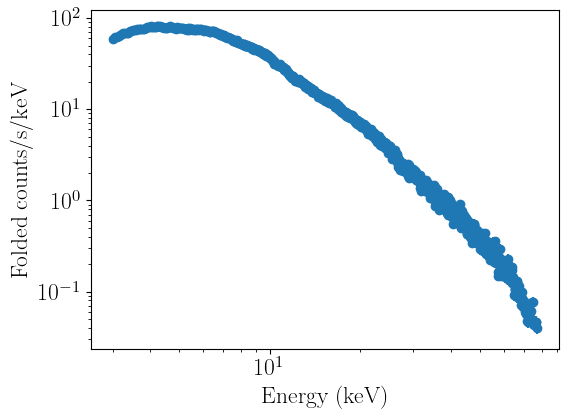

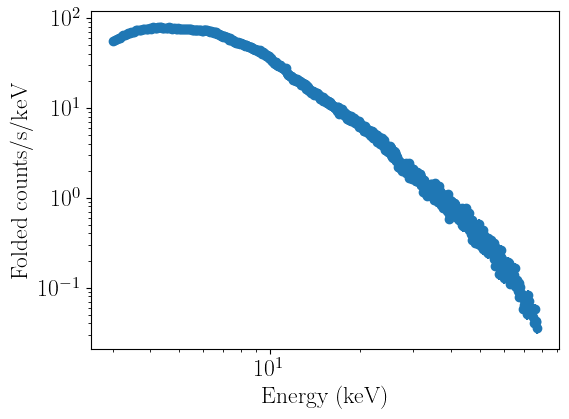

In [3]:
fpma_04_fit = fitspec.FitTimeAvgSpectrum()
fpma_04_fit.set_data(fpma_04,os.getcwd()+'/data/nu90401309004A01_sr_grp.pha',
                      background=os.getcwd()+'/data/nu90401309004A01_bk.pha')
fpma_04_fit.ignore_energies(0,3.0)
fpma_04_fit.ignore_energies(77.5,300.0)

fpmb_04_fit = fitspec.FitTimeAvgSpectrum()
fpmb_04_fit.set_data(fpmb_04,os.getcwd()+'/data/nu90401309004B01_sr_grp.pha',
                      background=os.getcwd()+'/data/nu90401309004B01_bk.pha')
fpmb_04_fit.ignore_energies(0,3.0)
fpmb_04_fit.ignore_energies(77.5,300.0)

fpma_04_fit.plot_data()
fpmb_04_fit.plot_data()

## Defining models

So far, we've loaded in the data and created two Fit objects, each with their own data. We now want to define the models we will use, and then model the data jointly.

First, we have to define our models, for which we will use nDspec's interface to the Xspec library of models. In this tutorial, we will limit ourselves to an absorbed disk+Comptonization model for simplicity.

In [4]:
model_library = XSModels.FortranInterface()

def nthcomp(ear, params):
    pass

def tbabs(ear, params):
    pass

def diskbb(ear, params):
    pass

model_library.load_models({
    "diskbb": diskbb,
    "tbabs": tbabs,
    "nthcomp": nthcomp
})

def ndspec_tbabs(ear,nH):
    par_array = np.array([nH])
    model = model_library.tbabs(ear,par_array)
    return model

#note that here we convert the disk normalization in Xspec to log10(normalization)
#this is because the log10 of the norm is linearly degenerate with the temperature,
#so using it as model input makes the job of optimizers/samplers easier.
def ndspec_diskbb(ear,Tin,norm_disk):
    norm_disk = 10**norm_disk
    par_array = np.array([Tin,norm_disk])
    model = model_library.diskbb(ear,par_array)
    return model

def ndspec_nthcomp(ear,Gamma,kT_e,kT_bb,norm_comp):
    par_array = np.array([Gamma,kT_e,kT_bb,1,0,norm_comp])
    model = model_library.nthcomp(ear,par_array)
    return model

 Solar Abundance Vector set to angr:  Anders E. & Grevesse N. Geochimica et Cosmochimica Acta 53, 197 (1989)
 Cross Section Table set to vern:  Verner, Ferland, Korista, and Yakovlev 1996


Then, we define the actual composite models now and set our _individual_ FitObjects to use those models.

In [5]:
#This would be "tbabs * (nthcomp + diskbb)" in XSPEC notation, 
#with the disk temperature tied to the seed photon temperature in nthcomp
spectral_model = LM_Model(ndspec_tbabs)*(LM_Model(ndspec_diskbb)+LM_Model(ndspec_nthcomp))

start_params = spectral_model.make_params(nH = dict(value=0.1,min=0.05,max=0.3,vary=True),
                                          Tin = dict(value=0.35,min=0.1,max=2,vary=True),
                                          norm_disk = dict(value=4,min=-1,max=6,vary=True),
                                          Gamma = dict(value=1.50,min=1.4,max=2.2,vary=True),
                                          kT_e = dict(value=200,min=20,max=400,vary=True),
                                          kT_bb = dict(value=0.35,min=0.1,max=2,vary=True,expr="1.0*Tin"),
                                          norm_comp = dict(value=0.1,min=0.001,max=30,vary=True),                                             
                                          )

fpma_04_fit.set_model(spectral_model,params=start_params)
fpmb_04_fit.set_model(spectral_model,params=start_params) 

## Combining the two and fit the data

Now that we have two models, we want to tell nDspec that they should be fit together and that parameters with identical names should be shared across all datasets. To do that, we're going to use ndspec's JointFit class. 

JointFit acts similar to a dictionary: it contains each FitObject next to a name, and adds functionality for performing joint fits and inference for each FitObject. In this way, the user-facing methods like ``eval_model``, ``get_resisuals`` etc remain unchanged, and under the hood nDspec is simply looping over the stored FitObjects, calling the appoprirate method, and returning the output normally. Importantly, you can still use the individual objects to perform individual fits like normal and you set the objects data and model individually (as we did above). 

In [6]:
from ndspec.JointFit import JointFit

nustar_joint = JointFit()
nustar_joint.add_fitobj(fpma_04_fit,"fpma")
nustar_joint.add_fitobj(fpmb_04_fit,"fpmb")
nustar_joint.model_params.pretty_print()

Name          Value      Min      Max   Stderr     Vary     Expr Brute_Step
Gamma           1.5      1.4      2.2     None     True     None     None
Tin            0.35      0.1        2     None     True     None     None
kT_bb          0.35      0.1        2     None    False  1.0*Tin     None
kT_e            200       20      400     None     True     None     None
nH              0.1     0.05      0.3     None     True     None     None
norm_comp       0.1    0.001       30     None     True     None     None
norm_disk         4       -1        6     None     True     None     None


Because our starting model is extremely simple, we can simply just run our fit as normal and then visualize the results. If you were using a more complex fit (say, a reflection model), you should instead tweak the parameters a bit before running the fit.

In [7]:
nustar_joint.fit_data()

-----------------------
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 224
    # variables        = 6
-----------------------
    Dataset: fpma
    fit statistic      = 4228.26276686132
    reduced statistic  = 3.298176885227239
    # data points      = 1288
    Dataset: fpmb
    fit statistic      = 4365.861868724975
    reduced statistic  = 3.3635299450885783
    # data points      = 1304
-----------------------
    total fit stat         = 8594.124635586295
    total reduced stat     = 3.3233273919513904
    total data points      = 2592
-----------------------
[[Parameters]]
    nH:         0.05002162 +/- 0.16040709 (320.68%) (init = 0.1)
    Tin:        0.46212979 +/- 0.02046079 (4.43%) (init = 0.35)
    norm_disk:  3.82210575 +/- 0.23814911 (6.23%) (init = 4)
    Gamma:      1.56654580 +/- 0.00867704 (0.55%) (init = 1.5)
    kT_e:       213.793410 +/- 0.14224570 (0.07%) (init = 200)
    kT_bb:      0.46212979 +/- 0.02046079 (4.43%) == '1.0*Tin'
    n

We now want to visualize the results of our fit. The ``JointFit`` class provides two methods to do this. 

``all_plots`` loops over all the stored FitObjects and calls each individual ``plot_model`` method in a separate window. This method is particularly appropriate for plotting datasets that do not share the same information (say, a lag spectrum and a time-averaged spectrum fitted together.

``joint_plots`` is more apporpriate for our use case, as it performs the same functionality, but uses the same figure for all the fitter objects:

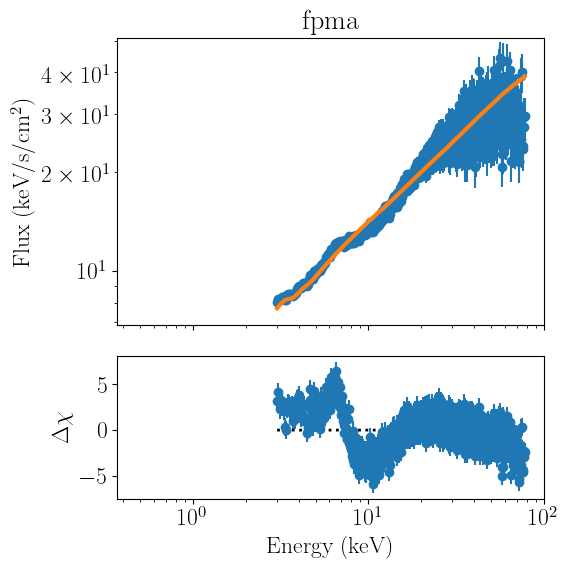

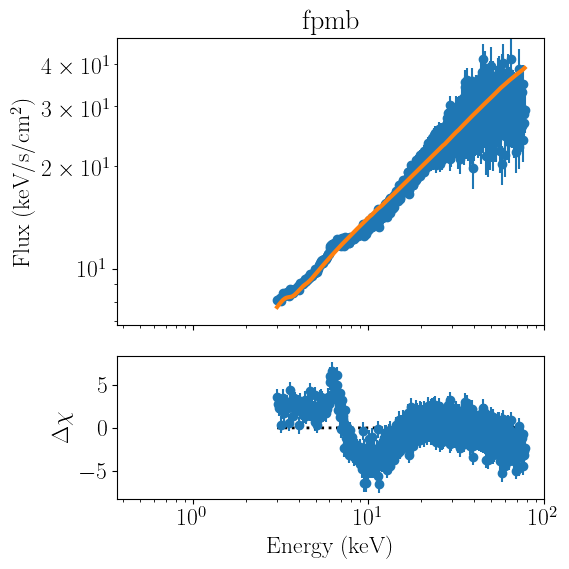

In [8]:
nustar_joint.all_plots(units='eeunfold')

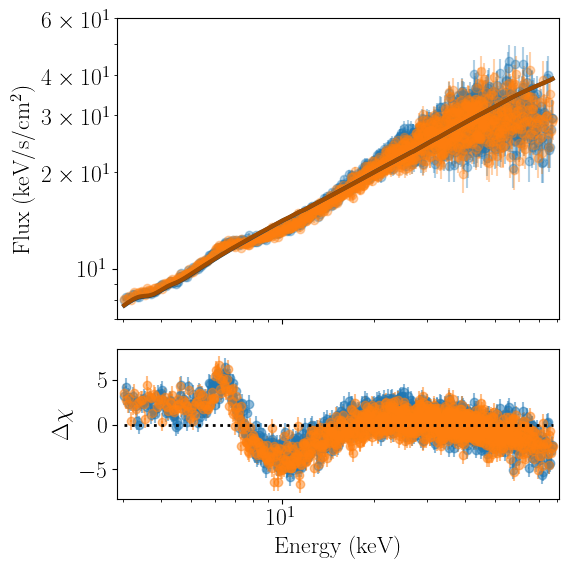

In [9]:
nustar_joint.joint_plot(units='eeunfold',xrange=[3,78],yrange=[7,60])

Finally, we can attempt to refine our fit a bit. It is common when modelling data from different detector to include a cross-calibration constant, which will be fixed to one for a 'reference' detector, and be allowed to vary for the others, in order to accoutn for uncertainties in the cross-calibration of the instrument.

In nDspec, this is accomplished by calling the ``renorm_timeavg`` method of the joint fit:

In [10]:
nustar_joint.renorm_timeavg(True)
nustar_joint.model_params.pretty_print()

Name            Value      Min      Max   Stderr     Vary     Expr Brute_Step
Gamma           1.567      1.4      2.2 0.008677     True     None     None
Tin            0.4621      0.1        2  0.02046     True     None     None
kT_bb          0.4621      0.1        2  0.02046    False  1.0*Tin     None
kT_e            213.8       20      400   0.1422     True     None     None
nH            0.05002     0.05      0.3   0.1604     True     None     None
norm_comp       4.225    0.001       30  0.08946     True     None     None
norm_disk       3.822       -1        6   0.2381     True     None     None
renorm_fpma         1      0.5      1.5     None     True     None     None
renorm_fpmb         1      0.5      1.5     None     True     None     None


In [11]:
nustar_joint.model_params['renorm_fpma'].vary=False
nustar_joint.model_params['renorm_fpmb'].value=0.95

-----------------------
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 163
    # variables        = 7
-----------------------
    Dataset: fpma
    fit statistic      = 3906.5562237307963
    reduced statistic  = 3.049614538431535
    # data points      = 1288
    Dataset: fpmb
    fit statistic      = 3785.389444385545
    reduced statistic  = 2.9185732030728953
    # data points      = 1304
-----------------------
    total fit stat         = 7691.945668116341
    total reduced stat     = 2.9756076085556447
    total data points      = 2592
-----------------------
    nH:           at boundary
[[Parameters]]
    nH:           0.05000029 +/- 0.04165207 (83.30%) (init = 0.05002162)
    Tin:          0.46431506 +/- 0.01050497 (2.26%) (init = 0.4621298)
    norm_disk:    4.16541873 +/- 0.10151906 (2.44%) (init = 3.822106)
    Gamma:        1.57401937 +/- 0.00206623 (0.13%) (init = 1.566546)
    kT_e:         213.708342 +/- 0.10071648 (0.05%) (init = 213.7934

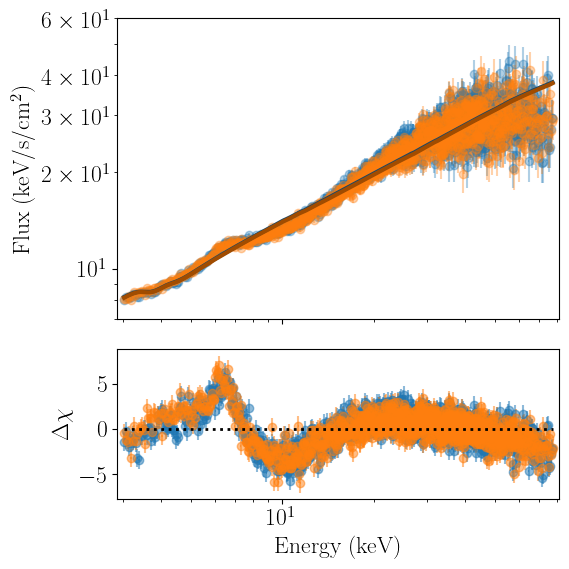

In [12]:
nustar_joint.fit_data()
nustar_joint.joint_plot(units='eeunfold',xrange=[3,78],yrange=[7,60])

It looks like our fit improved marginally, but in this particular case the flux difference between the two detector is minor.

From here, users might want to perform inference on their joint fit in order to estabilish posterior distributions, Bayesian evidence, etc. Doing so is identical to the one-dimensional case discussed in the [Bayesian inference tutorial](bayesian_sampling.ipynb); you would simply pass the JointFit object to the nDspec sampling utlity functions.